In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix

(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [13]:
print("My train data Shape:", train_data.shape)
print("My train labels :", train_labels.shape)
print("Maximum label : ", train_labels.max())

My train data Shape: (60000, 28, 28)
My train labels : (60000,)
Maximum label :  9


Text(0.5, 1.0, 'Bag')

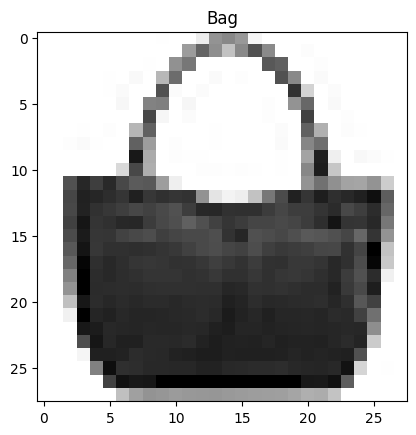

In [14]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
index_of_choice = 100
plt.imshow(train_data[index_of_choice],cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

In [15]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape= train_data[0].shape),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

model_1.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["Accuracy"])

non_norm_history = model_1.fit(train_data,train_labels,epochs=10,validation_data=(test_data, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 295us/step - Accuracy: 0.0984 - loss: 2.3277 - val_Accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 271us/step - Accuracy: 0.0974 - loss: 2.3028 - val_Accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 266us/step - Accuracy: 0.0984 - loss: 2.3028 - val_Accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - Accuracy: 0.0991 - loss: 2.3028 - val_Accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 260us/step - Accuracy: 0.0989 - loss: 2.3028 - val_Accuracy: 0.1000 - val_loss: 2.3027
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 263us/step - Accuracy: 0.1001 - loss: 2.3028 - val_Accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 260us/step - Accuracy: 0.0983 - loss: 2.3028 - val_Accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 264us/step - Accuracy: 0.0985 -

In [16]:
train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape= train_data[0].shape),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(0.001),
                metrics = ["Accuracy"])
norm_history = model.fit(train_data_norm,train_labels,epochs=10,validation_data=(test_data_norm, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 288us/step - Accuracy: 0.5626 - loss: 1.3161 - val_Accuracy: 0.7343 - val_loss: 0.8825
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 275us/step - Accuracy: 0.7574 - loss: 0.7616 - val_Accuracy: 0.7627 - val_loss: 0.7124
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 266us/step - Accuracy: 0.7733 - loss: 0.6705 - val_Accuracy: 0.7696 - val_loss: 0.6792
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - Accuracy: 0.7825 - loss: 0.6367 - val_Accuracy: 0.7656 - val_loss: 0.6811
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - Accuracy: 0.7874 - loss: 0.6181 - val_Accuracy: 0.7820 - val_loss: 0.6457
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 256us/step - Accuracy: 0.7919 - loss: 0.6045 - val_Accuracy: 0.7876 - val_loss: 0.6316
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 263us/step - Accuracy: 0.7952 - loss: 0.5972 - val_Accuracy: 0.7876 - val_loss: 0.6267
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 257us/step - Accuracy: 0.7964 -

In [19]:
import random
def plot_random_image(model, images, true_labels, classes):
  i = random.randint(0, len(images))
  image_to_predict = images[i]
  true_positive_image = classes[true_labels[i]]
  pred_probs = model.predict(tf.expand_dims(image_to_predict, axis=0))
  predicted_image = classes[pred_probs.argmax()]
  
  plt.imshow(image_to_predict, cmap=plt.cm.binary)
  if(predicted_image == true_positive_image):
    color = "green"
  else:
    color = "red"

  plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(predicted_image,
                                                    100*tf.reduce_max(pred_probs),
                                                    true_positive_image),color=color)
  
plot_random_image(model_4,test_data_norm,test_labels,class_names)

NameError: name 'model_4' is not defined